# SIR Agent-Based Model

This model is the same  as the AnyLogic example model "SIR Agent-Based Networks.". 
This model currently support three types of networks:
  1. Random (if the parameter "p_random_connect" = 1.0)
  2. Ring lattice (if the parameter "p_random_connect" = 0.0)
  3. Small world (if the parameter "p_random_connect":  0.0 < p_random_connect < 1.0 )
      it indicates that there are "p_random_connect" percentage connections are radom connections, and 
      ( 1 - "p_random_connect" ) percentage connections are connections are Ring lattice connections.
This example model in Anylogic can be found: https://cloud.anylogic.com/model/7088e817-1dab-42b1-89fe-b19bc0a823e1?mode=SETTINGS

## Setup

First, import required code with `using` and perform other setup tasks.

In [ ]:
using Makie, CairoMakie
using StateCharts
using AlgebraicABMs
using Catlab
using DataMigrations

ENV["JULIA_DEBUG"] = "AlgebraicABMs"; 


# TODO: add positions of nodes and have the positions stable
# https://stackoverflow.com/questions/13938770/how-to-get-the-coordinates-from-layout-from-graphviz
# solution of get the positions of nodes of graphviz

# TODO:
# https://stackoverflow.com/questions/5343899/how-to-force-node-position-x-and-y-in-graphviz
# solution of plot graphviz with the node positions

## Define the Parameters

In [ ]:
total_population = 50 # Unit: persons
frac_initial_infected = 0.02
contact_rate = 5 # Unit: contacts per day
infectivity = 0.01
average_illness_duration = 15 # days
# parameters define the network
average_connections = 2
p_random_connect = 0.9

## Create the StateChart

function UnitStateChartF takes in 3 input argummapents:
1. states: tuple/array of all states
2. transitions: tuple/array of all transitions. The syntax of each transition: `transition_name => (source_state => target_state, tranisiton_type => values)`
3. alternative transitions: tuple/array of all alternative transitions. The syntax of each altanative transition: `:source_transition_name=>((alternative_transition_name, probability_value) => target_state)`

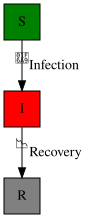

In [3]:
states = [:S, :I, :R] # define the states
transitions = [ :Infection => (:S => :I, :Pattern => 1), :Recovery => (:I => :R, :Rate => 1.0 / average_illness_duration)]
alternatives = [] # this model does not include alternative transitions
SIRStatechart = UnitStateChartF(states, transitions, alternatives)

stateColors = Dict(:S => "green",:I => "red",:R => "gray"); # argument define colors of each state in StateChart
StateCharts.Graph(SIRStatechart, stateColors = stateColors)

## Create the Model Schema

Generate the model schema by composing auto state chart schema and the network schema

Define the persons object named :V, because we plan to compose the schema_statechart with graph schema by identifying ":V"

In [ ]:
schema_statechart = StateChartABMSchema_MultipleObjects(SIRStatechart,:V) |> schemaACSet |> schemaPresent

Compose the state chart schema with the network schema (symmetric reflective graph) as the ABM model schema (without equations)

In [ ]:
schema_model_without_equations = compose(Open([:S],schemaACSet(schema_statechart),[:V]), Open([:V],schemaACSet(SchUndirectedReflectiveNetwork),[:E])) |> apex |> schemaPresent 

Add the composition equations of the model schema, since those equations disapper after composition. This would be fixed in the future using GATlab


In [6]:
@present schema_model <: schema_model_without_equations begin
    compose(inv,inv) == id(E)
    compose(inv,src) == tgt
    compose(inv,tgt) == src
    compose(refl, src) == id(V)
    compose(refl, tgt) == id(V)
    compose(refl, inv) == refl 
end;

@acset_type SIRModelStaticNet(schema_model, index=[:src,:tgt]){Symbol} <: AbstractSymmetricReflexiveGraph

SIRModelStaticNet (alias for var"##SIRModelStaticNet#225"{Symbol})

### Show the Model Schema

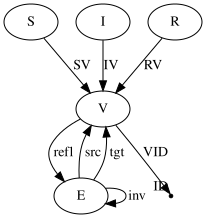

In [7]:
to_graphviz(schema_model; prog="dot")

## Data Migration

Data Migration from the ACSet with schema -- schema_statechart to the ACSet with schema -- schema_model

Define the data migration rule to automatically migrate ACSets from pure state chart schema to the composed model schema.

In [ ]:
const migrate_rule = @migration schema_model schema_statechart begin
    V => V; 
    ID=>ID; VID => VID
    S => S; SV => SV
    I => I; IV => IV
    R => R; RV => RV

    E => @product begin
        p1::V
        p2::V
    end
    src => p1
    tgt => p2
    inv => begin
        p1 => p2
        p2 => p1
    end
end

Define the user_defined rewrite rules: rewrite rules for contacts of Infectives. Note that each transitions_rule has a pair: timer=>rule

In [ ]:
transition_rules = [ ContinuousHazard( 1.0 / (contact_rate * infectivity)) => make_infectious_rule_MultipleObjects(SIRStatechart, [[:S],[:I]],[:I],[[:I],[:I]], :V; use_DataMigration = true, acset = SIRModelStaticNet, migration_rule = migrate_rule)]

## Define the Network

In [10]:
network = smallworldNetWork(Int(total_population), average_connections, p_random_connect);

## Create and Initialize the Model

In the initialization, randomly assign "total_population * frac_initial_infected" persons as Infectives (state I), and the rest persons are all Susceptibles (state S)

In [ ]:
init = radomlyAssignInitialInfectives(SIRModelStaticNet(), Int(total_population), Int(frac_initial_infected * total_population); obn=:V, network = network)
abm = make_ABM(SIRStatechart, transition_rules, :V; is_schema_singObject=false, use_DataMigration=true, acset = SIRModelStaticNet, migration_rule = migrate_rule)

## Run the Model

In [ ]:
res = run!(abm, init; maxtime=50.0);

## Visualize the Results

Plot the time series of each state

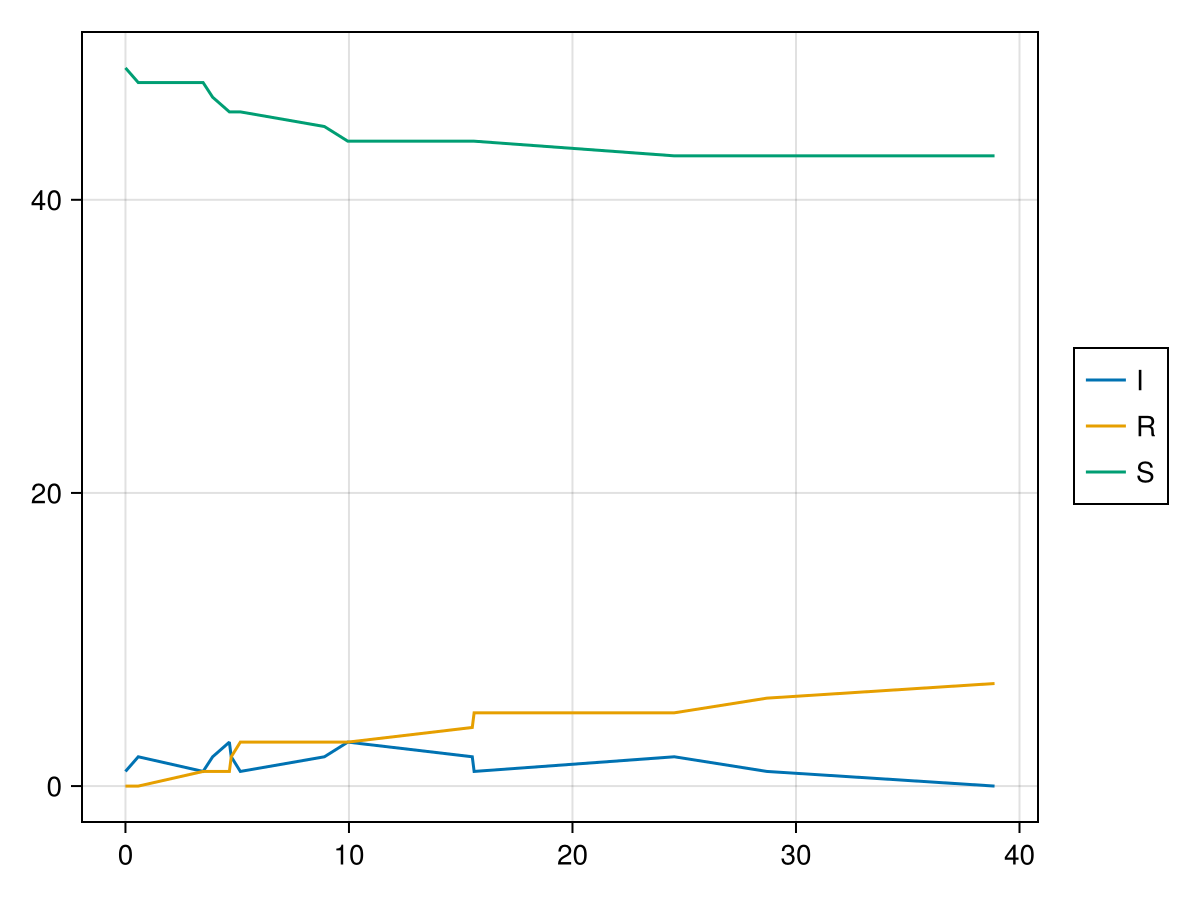

In [16]:
Makie.plot(res; Dict(o=>X->nparts(X,o) for o in states)...)

Show the networks at some time `t`

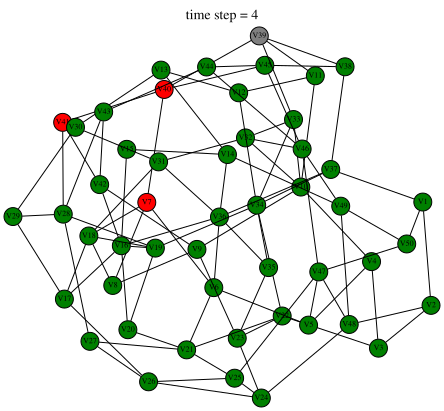

In [19]:
t = 4
StateCharts.Graph(res,t,stateColors)